# Practica 4: Detección Multicolinealidad

## Multicolinealidad

In [16]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pylab as plt
#!pip install wooldridge
from wooldridge import *

In [17]:
datos=dataWoo("hprice1")
y=datos["lprice"]
vars=["llotsize", "lsqrft", "bdrms"]
X=datos[vars]

mco1 = sm.OLS(y, sm.add_constant(X)).fit()
mco1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lprice   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     50.42
Date:                Mon, 06 Nov 2023   Prob (F-statistic):           9.74e-19
Time:                        08:57:15   Log-Likelihood:                 25.861
No. Observations:                  88   AIC:                            -43.72
Df Residuals:                      84   BIC:                            -33.81
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2970      0.651     -1.992      0.050      -2.592      -0.002
llotsize       0.1680      0.038      4.388      0.000       0.092       0.244
lsqrft         0.7002      0.093      7.540      0.000       0.516       0.885
bdrms          0.0370      0.028      1.342      0.183      -0.018       0.092
==============================================================================
Omnibus:                       12.060   Durbin-Watson:                   2.089
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               34.889
Skew:                          -0.188   Prob(JB):                     2.65e-08
Kurtosis:                       6.062   Cond. No.                         410.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
mco1.condition_number #Número de Condición

409.51474625747187

In [19]:
import statsmodels.stats.outliers_influence as oi

vifs=[oi.variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

[284.46202849274715, 320.08665791337097, 22.243172883072834]

In [20]:
vars

['llotsize', 'lsqrft', 'bdrms']

In [21]:
corr_matrix=np.corrcoef(X.T)
print(corr_matrix)

[[1.         0.31129925 0.16949022]
 [0.31129925 1.         0.51957927]
 [0.16949022 0.51957927 1.        ]]


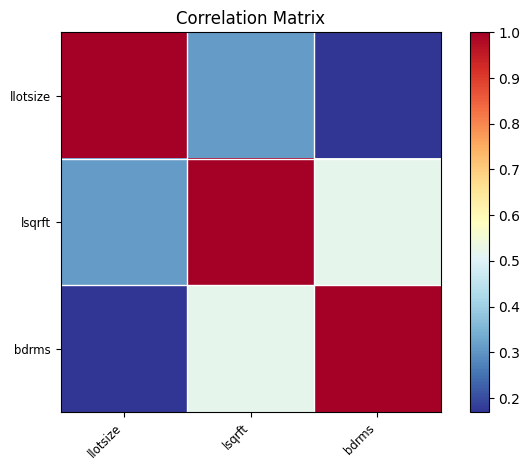

In [22]:
import statsmodels.graphics.api as smg
smg.plot_corr(corr_matrix, xnames=["llotsize", "lsqrft", "bdrms"])
plt.show()

# Linealidad de los residuos

In [24]:
import statsmodels.stats.diagnostic as diagn #Para el test de Harvey-Collier

###H0: El modelo es lineal

diagn.linear_harvey_collier(mco1)
#mco1.summary()

TtestResult(statistic=-0.5552330355706276, pvalue=0.5802109276867278, df=84)

# Normalidad de los Residuos

- Jarque-Bera: Test de hipótesis que contrasta si los datos de la muestra tienen el coeficiente de simetría y la curtósis de una distribución normal.
- $\chi^2$ (p-valor): p-valor del Test de Jaque-Bera.
- Skew: Coeficiente de Simetría de pearson de los residuos.
- Kurtosis: Coeficiente de apuntamiento de los residuos.
- Komogorov-Smirnov: Test de Hipótesis para contrastar si una muestra proviene de una distribución (en este caso normal).

In [26]:
import statsmodels.stats.api as sms
name = ['Jarque-Bera Est', 'Jarque-Vera p-val', 'Skew', 'Kurtosis']
test = sms.jarque_bera(mco1.resid)
for i in range(4):
    print(name[i], test[i])

Jarque-Bera Est 34.889445828407545
Jarque-Vera p-val 2.653707794334698e-08
Skew -0.18756944389904479
Kurtosis 6.061792648532739


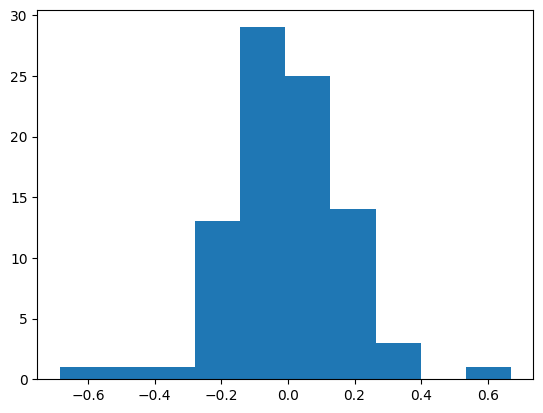

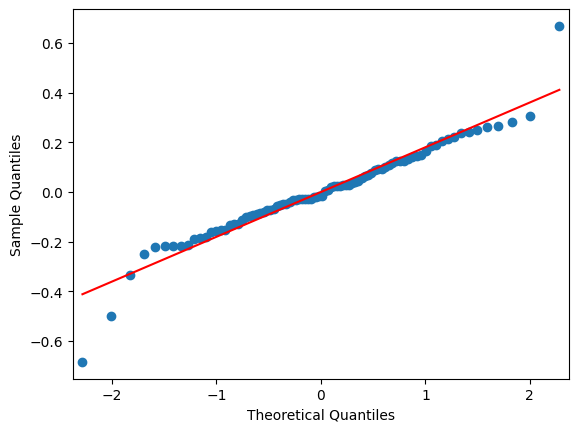

In [27]:
from matplotlib import pyplot
from statsmodels.graphics.gofplots import qqplot
pyplot.hist(mco1.resid)
pyplot.show()
qqplot(mco1.resid, line='s')
pyplot.show()

In [28]:
import statsmodels.stats.diagnostic as diag

diag.kstest_normal(mco1.resid)

(0.06649909936772953, 0.48573382397460296)

# Bootstrap

In [29]:
datos=dataWoo("hprice1")
y=datos["lprice"]
vars=["llotsize", "lsqrft", "bdrms"]
X=datos[vars]

mco1=sm.OLS(y, sm.add_constant(X)).fit()


from random import choices

beta=[]
n=len(y)
for it in range(10000): #repetimos 1000 veces la estimacion
    I=choices(list(range(n)), k=n) # elegimos una muestra con repeticion de los datos
    mco3 = sm.OLS(y[I], sm.add_constant(X.values[I,:])).fit() #ajustamos el modelo
    beta.append(list(mco3.params)) # guardamos los coeficientes
beta=np.array(beta)
k=len(X.T)+1
for i in range(k):
    q025=np.percentile(beta[:,i], 2.5) #percentil 2.5%
    q975=np.percentile(beta[:,i], 97.5) #percentil 97.5%
    media=np.mean(beta[:,i]) #media de los betas
    sd=np.std(beta[:,i]) #desviación tipica de los betas
    print(i, media,[q025, q975])


0 -1.348708525863981 [-3.010090388998048, 0.13636093500963992]
1 0.18165054785889273 [0.10732375586087023, 0.3174732491375041]
2 0.6923574891786564 [0.4631555138318429, 0.9238056919246643]
3 0.03371940979297704 [-0.03744370738356176, 0.08858196140729972]


In [ ]:
mco1.summary()

In [ ]:
import statsmodels.stats.diagnostic as diagn #Para el test de Harvey-Collier

diagn.linear_harvey_collier(mco1)
mco1.summary()